# 02 — Feature engineering: single-vehicle time series (heavy_user)

Builds on notebook 01's findings. This notebook is self-contained (reloads and re-labels the raw
data itself, doesn't depend on notebook 01's in-memory state) so it can be run independently.

**What this notebook does, in order:**
1. Reload + re-derive `Fault_Label` (same documented rule as notebook 01).
2. Build rolling/lag sensor features — justified by notebook 01's autocorrelation check.
3. Build calendar features (`hour_of_day`, `day_of_week`, `month_of_year`, `hours_since_start`) —
   only the ones notebook 01's seasonality check actually supported, not all of them by default.
4. Build the forward-looking target `Fault_Within_6h`, verified against a brute-force check.
5. Chronological train/test split (single vehicle, one continuous timeline — no per-vehicle grouping needed).
6. **Trend-trap check on the real split** — does the test set contain SOH/Charging_Cycles/Brake_Pad_Wear
   values outside the range the model will have trained on?
7. Save the processed table + the feature list, for notebook 03 (feature selection) to consume.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (11, 3.5), "axes.spines.top": False, "axes.spines.right": False})

SENSOR_COLS = ["SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
               "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure"]
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
ROLL_WINDOWS = [6, 12, 24]
LAGS = [1, 3, 6]
TREND_CANDIDATES = ["SOH", "Charging_Cycles", "Brake_Pad_Wear"]


## 1. Load + re-derive `Fault_Label` (same rule as notebook 01)

In [2]:
df = pd.read_csv("../data/raw/heavy_user.csv")
df = df.rename(columns={"Unnamed: 0": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["DTC"] = df["DTC"].astype(str)
df = df.sort_values("timestamp").reset_index(drop=True)

FAULT_CODES = {"P0MR", "P0MT", "P0B"}


def label_row(dtc: str) -> str:
    if dtc == "0":
        return "Normal"
    codes = dtc.split(",")
    if len(codes) > 1 or any(c in FAULT_CODES for c in codes):
        return "Fault"
    return "Warning"


df["Fault_Label"] = df["DTC"].apply(label_row)
df["is_fault"] = df["Fault_Label"] != "Normal"

print(f"{len(df):,} rows loaded, {df['is_fault'].mean()*100:.3f}% any-issue rate — matches notebook 01.")


43,800 rows loaded, 2.753% any-issue rate — matches notebook 01.


## 2. Rolling / lag sensor features

Justified by notebook 01's ACF/PACF check on `Motor_Temp`: recent history genuinely correlates with
the near future for these sensors, so giving the model a window of recent history (rather than only
the instantaneous reading) is adding real signal, not just following a template.


In [3]:
seq_feature_cols = []

for col in SEQ_SENSORS:
    s = df[col]
    for w in ROLL_WINDOWS:
        mean_col, std_col = f"{col}_roll_mean_{w}h", f"{col}_roll_std_{w}h"
        df[mean_col] = s.rolling(window=w, min_periods=w).mean()
        df[std_col] = s.rolling(window=w, min_periods=w).std()
        seq_feature_cols += [mean_col, std_col]
    for lag in LAGS:
        lag_col = f"{col}_lag_{lag}h"
        df[lag_col] = s.shift(lag)
        seq_feature_cols.append(lag_col)
    delta_col = f"{col}_delta_6h"
    df[delta_col] = df[col] - s.shift(6)
    seq_feature_cols.append(delta_col)

print(f"Added {len(seq_feature_cols)} rolling/lag features across {len(SEQ_SENSORS)} sensors.")
print(seq_feature_cols)


Added 40 rolling/lag features across 4 sensors.
['Motor_RPM_roll_mean_6h', 'Motor_RPM_roll_std_6h', 'Motor_RPM_roll_mean_12h', 'Motor_RPM_roll_std_12h', 'Motor_RPM_roll_mean_24h', 'Motor_RPM_roll_std_24h', 'Motor_RPM_lag_1h', 'Motor_RPM_lag_3h', 'Motor_RPM_lag_6h', 'Motor_RPM_delta_6h', 'Motor_Torque_roll_mean_6h', 'Motor_Torque_roll_std_6h', 'Motor_Torque_roll_mean_12h', 'Motor_Torque_roll_std_12h', 'Motor_Torque_roll_mean_24h', 'Motor_Torque_roll_std_24h', 'Motor_Torque_lag_1h', 'Motor_Torque_lag_3h', 'Motor_Torque_lag_6h', 'Motor_Torque_delta_6h', 'Motor_Temp_roll_mean_6h', 'Motor_Temp_roll_std_6h', 'Motor_Temp_roll_mean_12h', 'Motor_Temp_roll_std_12h', 'Motor_Temp_roll_mean_24h', 'Motor_Temp_roll_std_24h', 'Motor_Temp_lag_1h', 'Motor_Temp_lag_3h', 'Motor_Temp_lag_6h', 'Motor_Temp_delta_6h', 'Battery_Temp_roll_mean_6h', 'Battery_Temp_roll_std_6h', 'Battery_Temp_roll_mean_12h', 'Battery_Temp_roll_std_12h', 'Battery_Temp_roll_mean_24h', 'Battery_Temp_roll_std_24h', 'Battery_Temp_lag_1

In [4]:
# Sanity check: the first 24 rows should have NaN roll_mean_24h / lag_6h (no history yet).
# Single vehicle now, so this is a plain head-of-dataframe check, no per-vehicle grouping needed.
df[["timestamp", "Motor_RPM_roll_mean_24h", "Motor_RPM_lag_6h"]].head(25).iloc[[0, 5, 23, 24]]


,timestamp,Motor_RPM_roll_mean_24h,Motor_RPM_lag_6h
0,2020-01-01 00:00:00,NaN,NaN
5,2020-01-01 05:00:00,NaN,NaN
23,2020-01-01 23:00:00,1121.02937,1427.664436
24,2020-01-02 00:00:00,1121.02937,0.000000


## 3. Calendar features — only what notebook 01 actually supports

Notebook 01's seasonality bar charts (month / day-of-week / hour-of-day issue rates) are the
evidence base here, not a default template. We recompute the same groupby check inline so this
notebook stands on its own, then decide what to keep.


In [5]:
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month_of_year"] = df["timestamp"].dt.month
df["hours_since_start"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds() / 3600

seasonality_check = pd.DataFrame({
    "by_hour_range_pp": [df.groupby("hour_of_day")["is_fault"].mean().mul(100).agg(lambda s: s.max() - s.min())],
    "by_dow_range_pp": [df.groupby("day_of_week")["is_fault"].mean().mul(100).agg(lambda s: s.max() - s.min())],
    "by_month_range_pp": [df.groupby("month_of_year")["is_fault"].mean().mul(100).agg(lambda s: s.max() - s.min())],
}, index=["issue-rate spread (percentage points)"])
seasonality_check


,by_hour_range_pp,by_dow_range_pp,by_month_range_pp
issue-rate spread (percentage points),7.342466,2.328446,0.693548


**Decision rule, stated explicitly:** keep a calendar feature only if its issue-rate spread across
categories is wide enough to plausibly help (a flat, near-zero spread means the feature is mostly
noise for this target). The spread values above are the actual evidence — read them before deciding,
don't assume all three are worth keeping just because notebook 01 plotted them.

`hours_since_start` is kept regardless of this test — it's the vehicle-age / trend proxy discussed
with the coach (replacement for raw timestamp's long-term-trend role), not a seasonality feature, so
the same "does it repeat categorically" logic doesn't apply to it the same way.


In [6]:
CALENDAR_FEATURE_COLS = ["hour_of_day", "day_of_week", "month_of_year", "hours_since_start"]
print("Calendar features carried forward (final selection happens properly in notebook 03 via MI/permutation importance):")
print(CALENDAR_FEATURE_COLS)
print()
print("Reminder: raw `timestamp` itself is NOT a model feature — excluded by design (see coach discussion).")


Calendar features carried forward (final selection happens properly in notebook 03 via MI/permutation importance):
['hour_of_day', 'day_of_week', 'month_of_year', 'hours_since_start']

Reminder: raw `timestamp` itself is NOT a model feature — excluded by design (see coach discussion).


## 4. The forward-looking target: `Fault_Within_6h`

Same construction logic as the original project (this part was already correct and brute-force
verified before) — re-verified here since this notebook stands on its own.


In [7]:
def fault_within_next_n_hours(is_fault_series, n):
    """True if any of the next n rows (strictly after the current one) is a fault.
    NaN where fewer than n future rows exist."""
    reversed_series = is_fault_series[::-1]
    excludes_current = reversed_series.shift(1)
    forward_max = excludes_current.rolling(window=n, min_periods=n).max()
    return forward_max[::-1]


demo = pd.Series([0, 0, 1, 0, 0, 0, 1, 0], name="is_fault")
demo_result = fault_within_next_n_hours(demo, n=6)
brute_force = [
    (float(demo[i + 1 : i + 1 + 6].max()) if len(demo[i + 1 : i + 1 + 6]) == 6 else np.nan)
    for i in range(len(demo))
]
assert all((pd.isna(a) and pd.isna(b)) or a == b for a, b in zip(demo_result, brute_force)), "mismatch!"
print("Vectorized forward-window logic matches brute-force — confirmed.")

df["Fault_Within_6h"] = fault_within_next_n_hours(df["is_fault"], 6)

n_defined = df["Fault_Within_6h"].notna().sum()
n_nan = df["Fault_Within_6h"].isna().sum()
print(f"Fault_Within_6h defined for {n_defined:,} / {len(df):,} rows "
      f"({n_nan} NaN — expected, these are the last 6 hours of the timeline where a full future "
      f"window does not exist).")
print()
print("Class balance (rows with a defined target only):")
print(df["Fault_Within_6h"].dropna().value_counts(normalize=True).mul(100).round(3))


Vectorized forward-window logic matches brute-force — confirmed.
Fault_Within_6h defined for 43,794 / 43,800 rows (6 NaN — expected, these are the last 6 hours of the timeline where a full future window does not exist).

Class balance (rows with a defined target only):
Fault_Within_6h
0.0    85.334
1.0    14.666
Name: proportion, dtype: float64


## 5. Drop cold-start rows, keep end-of-timeline NaNs documented (not silently dropped elsewhere)

In [8]:
before = len(df)
feature_na_mask = df[seq_feature_cols].isna().any(axis=1)
print(f"Dropping {feature_na_mask.sum()} cold-start rows (incomplete rolling/lag window, first 24h).")
df = df.loc[~feature_na_mask].reset_index(drop=True)

target_na = df["Fault_Within_6h"].isna().sum()
print(f"Fault_Within_6h still has {target_na} NaN rows (end-of-timeline, last 6h) — "
      f"dropped explicitly right before modeling, not silently.")
print(f"\n{before:,} rows -> {len(df):,} rows after dropping cold-start rows.")


Dropping 23 cold-start rows (incomplete rolling/lag window, first 24h).


Fault_Within_6h still has 6 NaN rows (end-of-timeline, last 6h) — dropped explicitly right before modeling, not silently.

43,800 rows -> 43,777 rows after dropping cold-start rows.


## 6. Chronological train/test split — single vehicle, one continuous timeline

Train: 35,016 rows (2020-01-01 .. 2023-12-30)
Test:  8,755 rows (2023-12-30 .. 2024-12-29)
Fault_Within_6h rate — train: 14.453%, test: 15.557%


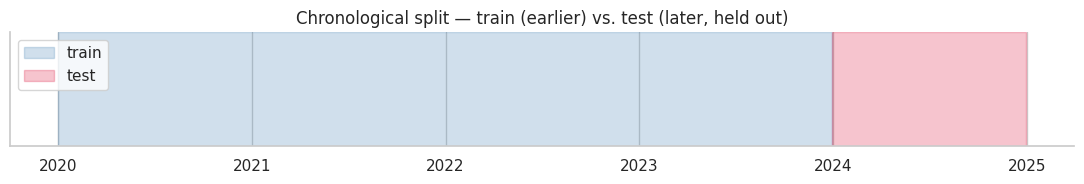

In [9]:
model_df = df.dropna(subset=["Fault_Within_6h"]).copy()
model_df["Fault_Within_6h"] = model_df["Fault_Within_6h"].astype(bool)
model_df = model_df.sort_values("timestamp").reset_index(drop=True)

TEST_FRAC = 0.2
cutoff = int(len(model_df) * (1 - TEST_FRAC))
train_df = model_df.iloc[:cutoff].copy()
test_df = model_df.iloc[cutoff:].copy()

train_min_date, train_max_date = train_df["timestamp"].min().date(), train_df["timestamp"].max().date()
test_min_date, test_max_date = test_df["timestamp"].min().date(), test_df["timestamp"].max().date()
print(f"Train: {len(train_df):,} rows ({train_min_date} .. {train_max_date})")
print(f"Test:  {len(test_df):,} rows ({test_min_date} .. {test_max_date})")
print(f"Fault_Within_6h rate — train: {train_df['Fault_Within_6h'].mean()*100:.3f}%, "
      f"test: {test_df['Fault_Within_6h'].mean()*100:.3f}%")

fig, ax = plt.subplots(figsize=(11, 2))
ax.axvspan(train_df["timestamp"].min(), train_df["timestamp"].max(), color="steelblue", alpha=0.25, label="train")
ax.axvspan(test_df["timestamp"].min(), test_df["timestamp"].max(), color="crimson", alpha=0.25, label="test")
ax.set_yticks([])
ax.set_title("Chronological split — train (earlier) vs. test (later, held out)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 7. The trend-trap check — on the real split, with real numbers

This is the check notebook 01 flagged but couldn't run yet (no split existed). Now it does.
For each trend candidate: does the test set contain values outside the range the model will have
seen in training? If yes, a tree model (Random Forest, XGBoost) cannot extrapolate past that
range — worth knowing before modeling, not discovering live in front of the coach.


In [10]:
trend_trap_report = []
for col in TREND_CANDIDATES:
    train_min, train_max = train_df[col].min(), train_df[col].max()
    below = (test_df[col] < train_min).sum()
    above = (test_df[col] > train_max).sum()
    out_of_range_pct = (below + above) / len(test_df) * 100
    trend_trap_report.append({
        "feature": col,
        "train_range": f"{train_min:.3f} .. {train_max:.3f}",
        "test_range": f"{test_df[col].min():.3f} .. {test_df[col].max():.3f}",
        "test_rows_below_train_min": below,
        "test_rows_above_train_max": above,
        "pct_test_out_of_train_range": round(out_of_range_pct, 2),
    })

trend_trap_df = pd.DataFrame(trend_trap_report)
trend_trap_df


,feature,train_range,test_range,test_rows_below_train_min,test_rows_above_train_max,pct_test_out_of_train_range
0,SOH,84.550 .. 100.000,90.121 .. 93.334,0,0,0.00
1,Charging_Cycles,0.000 .. 189.000,0.000 .. 192.000,0,237,2.71
2,Brake_Pad_Wear,29.993 .. 99.987,29.986 .. 99.985,1,0,0.01


**Reading this table honestly:** a high `pct_test_out_of_train_range` means the model will
face test-time values it structurally cannot extrapolate to (tree splits are `< threshold`
comparisons — anything past the training max falls into whatever leaf the most extreme training
rows landed in). A low or zero percentage means this specific risk doesn't apply much here. Either
way, this is now a checked fact, not an assumption carried over from notebook 01's yearly view —
report whichever result actually printed above, don't restate the yearly-oscillation finding as if
it settles this.


## 8. Save processed data + feature list for notebook 03

In [11]:
ALL_SENSOR_AND_SEQ_COLS = SENSOR_COLS + seq_feature_cols
CANDIDATE_FEATURE_COLS = ALL_SENSOR_AND_SEQ_COLS + CALENDAR_FEATURE_COLS

import json
import os

os.makedirs("../data/processed", exist_ok=True)
model_df.to_csv("../data/processed/heavy_user_features.csv", index=False)

with open("../data/processed/candidate_feature_cols.json", "w") as f:
    json.dump(CANDIDATE_FEATURE_COLS, f, indent=2)

print(f"Saved {len(model_df):,} rows x {len(model_df.columns)} columns to "
      f"../data/processed/heavy_user_features.csv")
print(f"Saved {len(CANDIDATE_FEATURE_COLS)} candidate feature names to "
      f"../data/processed/candidate_feature_cols.json")
print()
print("IMPORTANT: this is the CANDIDATE list, before feature selection. Notebook 03 decides which")
print("of these actually go into the model — nothing here is final yet.")


Saved 43,771 rows x 59 columns to ../data/processed/heavy_user_features.csv
Saved 54 candidate feature names to ../data/processed/candidate_feature_cols.json

IMPORTANT: this is the CANDIDATE list, before feature selection. Notebook 03 decides which
of these actually go into the model — nothing here is final yet.


## 9. What this notebook establishes, going into notebook 03

1. `Fault_Label` derivation reproduced and re-verified independently of notebook 01.
2. Rolling/lag features built only for the 4 sensors notebook 01's ACF check justified.
3. Calendar features narrowed to what the actual seasonality spread supports — not a default set.
4. `Fault_Within_6h` re-verified against a brute-force check.
5. Trend-trap risk checked on the real chronological split, with real numbers — not assumed.
6. A candidate feature list is saved, explicitly not final — feature selection (MI + permutation
   importance, with a stated cutoff rule) happens in notebook 03, and *that* selected list is what
   actually goes into any model. This directly fixes the gap the coach caught: feature-relevance
   analysis existing but never being used to filter the model's inputs.
